In [1]:
# =============================================================
# DEM-CAPS Health-Economic Analysis Notebook
# Maastricht University | 2024
# =============================================================

# Set working directory to project root
setwd("C:/Users/drhas/Documents/demcaps-hta")

# Load all modules
source("model/parameters.R")
source("model/markov_model.R")
source("model/sensitivity.R")
source("model/visualizations.R")
source("model/ipd_calibration.R")
source("model/causal_inference.R")
source("model/survival_rwe.R")
source("model/advanced_causal.R")
source("model/hta_extended.R")

cat("✓ All modules loaded\n")
cat(sprintf("Model: %d states | %d-year horizon\n",
            n_states, time_horizon_years))
cat(sprintf("Discount rates: costs=%.1f%% effects=%.1f%%\n",
            discount_costs * 100,
            discount_effects * 100))


Attaching package: 'plotly'


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:MASS':

    select


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:graphics':

    layout



Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'purrr'


The following object is masked from 'package:scales':

    discard




✓ All modules loaded
Model: 5 states | 20-year horizon
Discount rates: costs=4.0% effects=1.5%


In [2]:
# =============================================================
# SECTION 1: BASE-CASE RESULTS
# =============================================================

cat("=== Base-Case Model Results ===\n\n")

model_res <- run_full_model()
results   <- model_res$results

# Format for display
results_display <- results %>%
  dplyr::mutate(
    Total_Cost  = formatC(round(Total_Cost),
                           format = "d", big.mark = ","),
    Total_QALY  = round(Total_QALY, 3),
    Inc_Cost    = formatC(round(Inc_Cost),
                           format = "d", big.mark = ","),
    Inc_QALY    = round(Inc_QALY, 3),
    ICER        = dplyr::if_else(
      is.na(ICER), "—",
      paste0("EUR ", formatC(round(ICER),
                              format = "d",
                              big.mark = ","))),
    NMB_20k     = formatC(round(NMB_20k),
                           format = "d", big.mark = ",")
  )

print(results_display[, c("Arm", "Total_Cost",
                            "Total_QALY", "Inc_Cost",
                            "Inc_QALY", "ICER",
                            "NMB_20k")])

cat("\n--- Key findings ---\n")
psych <- results[results$Arm == "Psychosocial", ]
tech  <- results[results$Arm == "Technology", ]
combo <- results[results$Arm == "Combination", ]

cat(sprintf("Psychosocial ICER: EUR %s/QALY\n",
            formatC(round(psych$ICER),
                    format = "d", big.mark = ",")))
cat(sprintf("Technology ICER:   EUR %s/QALY\n",
            formatC(round(tech$ICER),
                    format = "d", big.mark = ",")))
cat(sprintf("Combination ICER:  EUR %s/QALY\n",
            formatC(round(combo$ICER),
                    format = "d", big.mark = ",")))

=== Base-Case Model Results ===

           Arm Total_Cost Total_QALY Inc_Cost Inc_QALY       ICER NMB_20k
1          SoC    144,463      1.753        0    0.000          —       0
2 Psychosocial    164,042      2.149   19,579    0.396 EUR 49,436 -11,658
3   Technology    160,110      1.978   15,647    0.224 EUR 69,787 -11,163
4  Combination    176,027      2.390   31,565    0.636 EUR 49,617 -18,841

--- Key findings ---
Psychosocial ICER: EUR 49,436/QALY
Technology ICER:   EUR 69,787/QALY
Combination ICER:  EUR 49,617/QALY


=== Disease State Trajectories ===

SoC — Year 20 state distribution:
  MCI             0.0%
  Mild_AD         0.0%
  Moderate_AD     0.0%
  Severe_AD       0.1%
  Death           99.9%

Psychosocial — Year 20 state distribution:
  MCI             0.0%
  Mild_AD         0.0%
  Moderate_AD     0.0%
  Severe_AD       0.2%
  Death           99.7%

Technology — Year 20 state distribution:
  MCI             0.0%
  Mild_AD         0.0%
  Moderate_AD     0.0%
  Severe_AD       0.2%
  Death           99.8%

Combination — Year 20 state distribution:
  MCI             0.0%
  Mild_AD         0.0%
  Moderate_AD     0.0%
  Severe_AD       0.4%
  Death           99.5%


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_area()`)."


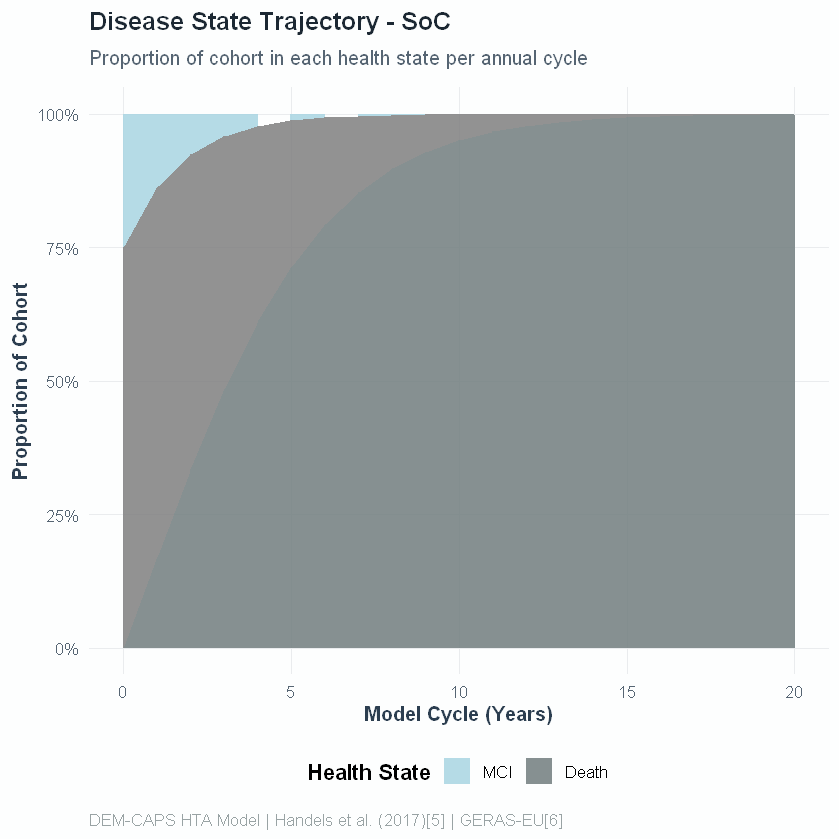

In [3]:
# =============================================================
# SECTION 2: DISEASE STATE TRAJECTORIES
# =============================================================

cat("=== Disease State Trajectories ===\n")

# Plot all 4 arms
par(mfrow = c(2, 2))

for (i in seq_along(model_res$arms)) {
  arm_name  <- model_res$arms[[i]]$arm
  arm_trace <- model_res$traces[[i]]

  df <- as.data.frame(arm_trace)
  df$Cycle <- 0:n_cycles

  cat(sprintf("\n%s — Year 20 state distribution:\n",
              arm_name))
  last_row <- df[nrow(df), health_states]
  for (s in health_states) {
    cat(sprintf("  %-15s %.1f%%\n",
                s, last_row[[s]] * 100))
  }
}

# Plot SoC trace using visualizations.R
p_soc <- plot_trace(model_res$traces[[1]],
                     arm        = "SoC",
                     use_plotly = FALSE)
print(p_soc)

In [11]:
# =============================================================
# SECTION 3: PROBABILISTIC SENSITIVITY ANALYSIS
# =============================================================

cat("=== Running PSA: 1000 simulations ===\n")

psa_df <- run_psa(n_sim = 1000, seed = 42)

cat("\nPSA Summary by arm:\n")
psa_summary <- psa_df %>%
  dplyr::group_by(Arm) %>%
  dplyr::summarise(
    mean_cost  = mean(Total_Cost,  na.rm = TRUE),
    mean_qaly  = mean(Total_QALY,  na.rm = TRUE),
    mean_icer  = mean(ICER,        na.rm = TRUE),
    pct_ce_20k = mean(NMB_20k > 0, na.rm = TRUE) * 100,
    pct_ce_50k = mean(NMB_50k > 0, na.rm = TRUE) * 100,
    .groups    = "drop"
  ) %>%
  dplyr::mutate(
    mean_cost  = formatC(round(mean_cost),
                          format = "d", big.mark = ","),
    mean_qaly  = round(mean_qaly, 3),
    mean_icer  = formatC(round(mean_icer),
                          format = "d", big.mark = ","),
    pct_ce_20k = round(pct_ce_20k, 1),
    pct_ce_50k = round(pct_ce_50k, 1)
  )

print(psa_summary)

cat("\nInterpretation:\n")
psych_ce <- psa_df %>%
  dplyr::filter(Arm == "Psychosocial") %>%
  dplyr::summarise(
    pct_ce_20k = mean(NMB_20k > 0) * 100,
    pct_ce_50k = mean(NMB_50k > 0) * 100
  )

cat(sprintf(
  "Psychosocial: %.1f%% prob CE at EUR 20k WTP\n",
  psych_ce$pct_ce_20k))
cat(sprintf(
  "Psychosocial: %.1f%% prob CE at EUR 50k WTP\n",
  psych_ce$pct_ce_50k))

=== Running PSA: 1000 simulations ===
Running PSA: 1000 simulations...
PSA complete. Valid simulations: 1000 

PSA Summary by arm:
# A tibble: 4 × 6
  Arm          mean_cost mean_qaly mean_icer pct_ce_20k pct_ce_50k
  <chr>        <chr>         <dbl> <chr>          <dbl>      <dbl>
1 Combination  178,788        2.39 55,231             0       28.2
2 Psychosocial 163,852        2.15 50,605             0       54.4
3 SoC          144,216        1.75 NA                 0        0  
4 Technology   159,925        1.98 75,937             0        3.1

Interpretation:
Psychosocial: 0.0% prob CE at EUR 20k WTP
Psychosocial: 54.4% prob CE at EUR 50k WTP


=== Cost-Effectiveness Plane ===



=== CEAC ===
CEAC at key WTP thresholds:
      WTP          Arm Prob_CE
1  20,000          SoC      0%
2  20,000 Psychosocial      0%
3  20,000   Technology    100%
4  20,000  Combination      0%
5  50,000          SoC     11%
6  50,000 Psychosocial   45.7%
7  50,000   Technology   42.7%
8  50,000  Combination    0.6%
9  80,000          SoC   80.6%
10 80,000 Psychosocial   18.7%
11 80,000   Technology    0.1%
12 80,000  Combination    0.6%


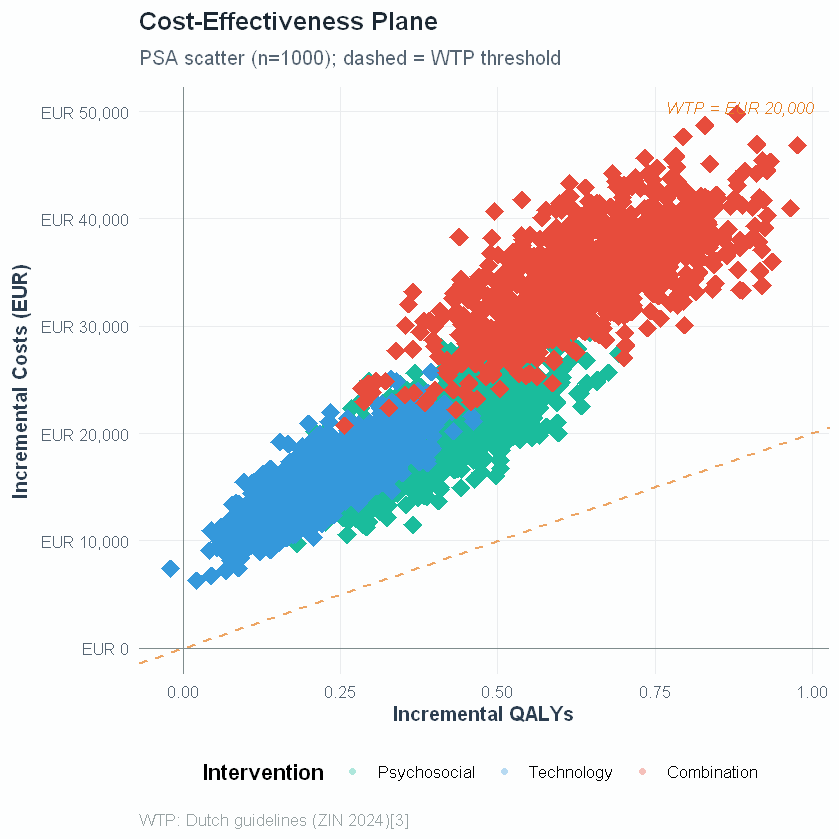

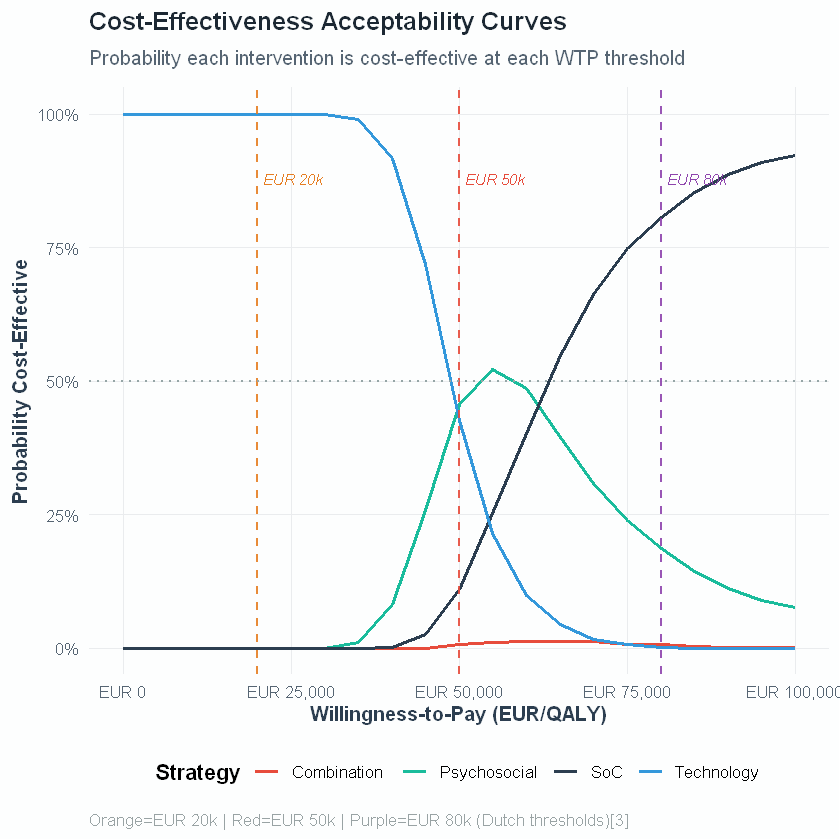

In [12]:
# =============================================================
# SECTION 4: CE PLANE AND CEAC
# =============================================================

# Force reload visualizations with new CEAC
source("model/visualizations.R")

cat("=== Cost-Effectiveness Plane ===\n")

# CE Plane
p_ce <- plot_ce_plane(psa_df,
                       wtp_line   = 20000,
                       use_plotly = FALSE)
print(p_ce)

cat("\n=== CEAC ===\n")

ceac_df <- calc_ceac(psa_df,
                      wtp = seq(0, 100000, by = 5000))

cat("CEAC at key WTP thresholds:\n")
key_wtp <- ceac_df %>%
  dplyr::filter(WTP %in% c(20000, 50000, 80000)) %>%
  dplyr::select(WTP, Arm, Prob_CE) %>%
  dplyr::mutate(
    WTP     = formatC(WTP, format = "d",
                       big.mark = ","),
    Prob_CE = paste0(round(Prob_CE * 100, 1), "%")
  )
print(key_wtp)

p_ceac <- plot_ceac(ceac_df, use_plotly = FALSE)
print(p_ceac)

=== One-Way DSA ===

Top 5 influential parameters:
                      Parameter ICER_Low Base_Value ICER_High ICER_Range
7         Discount rate - costs 72676.49      0.040  41555.07  31121.425
1 RR progression - psychosocial 43543.67      0.820  60399.55  16855.884
8       Discount rate - effects 45644.32      0.015  55746.47  10102.143
3             Utility - Mild AD 50926.43      0.650  48029.60   2896.827
4         Utility - Moderate AD 50203.78      0.470  48690.60   1513.182



=== Scenario Analysis ===

Scenario ICER summary (Psychosocial):
                                    Scenario Total_Cost Total_QALY   ICER
1                                  Base case    164,042      2.149 49,436
2            Early-stage dominant (MCI/Mild)    157,320      2.444 39,571
3      Late-stage dominant (Moderate/Severe)    178,127      1.491 83,344
4 Healthcare perspective (no informal costs)    164,042      2.149 49,436
5               Shortened horizon (10 years)    151,233      2.083 32,415
6 Technology cost halved (scale-up scenario)    164,042      2.149 49,436


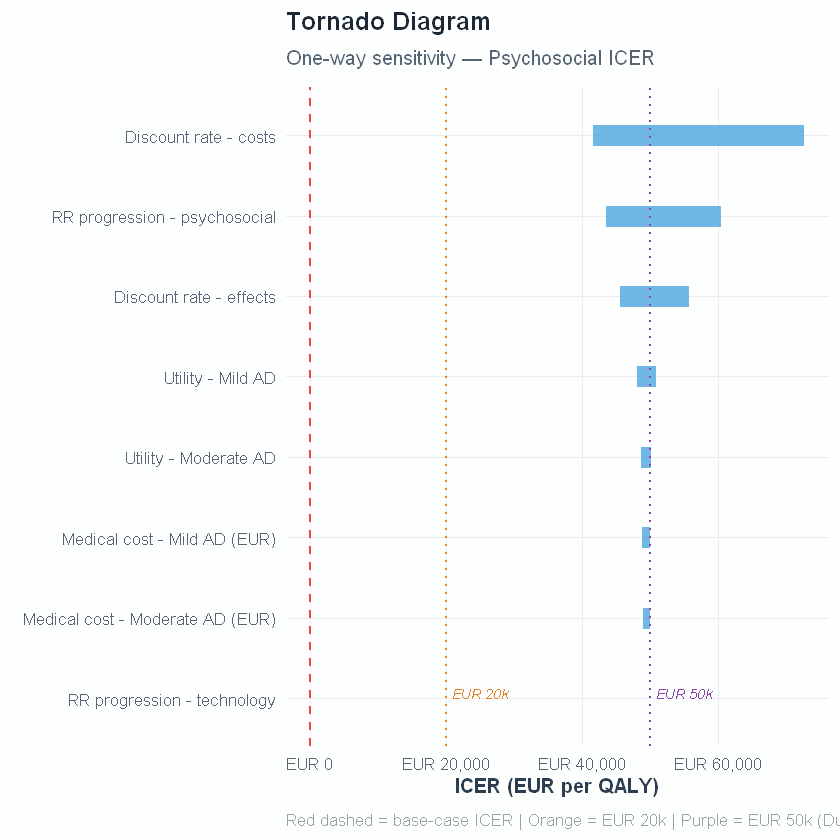

In [13]:
# =============================================================
# SECTION 5: SENSITIVITY ANALYSIS
# =============================================================

# Reload visualizations with updated tornado
source("model/visualizations.R")

cat("=== One-Way DSA ===\n")

dsa_df <- run_dsa()

cat("\nTop 5 influential parameters:\n")
print(dsa_df[1:5, c("Parameter", "ICER_Low",
                      "Base_Value", "ICER_High",
                      "ICER_Range")])

# Tornado plot
p_tornado <- plot_tornado(dsa_df, use_plotly = FALSE)
print(p_tornado)

cat("\n=== Scenario Analysis ===\n")

scenarios_df <- run_scenarios()

cat("\nScenario ICER summary (Psychosocial):\n")
scen_summary <- scenarios_df %>%
  dplyr::filter(Arm == "Psychosocial",
                !is.na(ICER)) %>%
  dplyr::select(Scenario, Total_Cost,
                Total_QALY, ICER) %>%
  dplyr::mutate(
    Total_Cost = formatC(round(Total_Cost),
                          format = "d",
                          big.mark = ","),
    Total_QALY = round(Total_QALY, 3),
    ICER       = formatC(round(ICER),
                          format = "d",
                          big.mark = ",")
  )
print(scen_summary)

=== IPD Calibration Pipeline ===



Generating synthetic IPD: 500 patients, 5 years
NOTE: Synthetic data only — for pipeline testing.

Generated: 500 patients, 2270 records

=== DEM-CAPS IPD Calibration Pipeline ===
Method: counts

No IPD path — using synthetic data.
Generating synthetic IPD: 500 patients, 5 years
NOTE: Synthetic data only — for pipeline testing.

Generated: 500 patients, 2270 records

Transitions: 1770 pairs
Estimating transitions: method='counts'

IPD-estimated utilities:
# A tibble: 4 × 4
  health_state mean_util se_util     n
  <chr>            <dbl>   <dbl> <int>
1 MCI              0.743 0.0116    123
2 Mild_AD          0.669 0.00656   426
3 Moderate_AD      0.464 0.00668   501
4 Severe_AD        0.274 0.00658   720

IPD-estimated informal care costs (EUR/year):
# A tibble: 4 × 4
  health_state mean_cost se_cost     n
  <chr>            <dbl>   <dbl> <int>
1 MCI              9108.    569.   123
2 Mild_AD         20750.    640.   426
3 Moderate_AD     39052.    720.   501
4 Severe_AD       58171.    

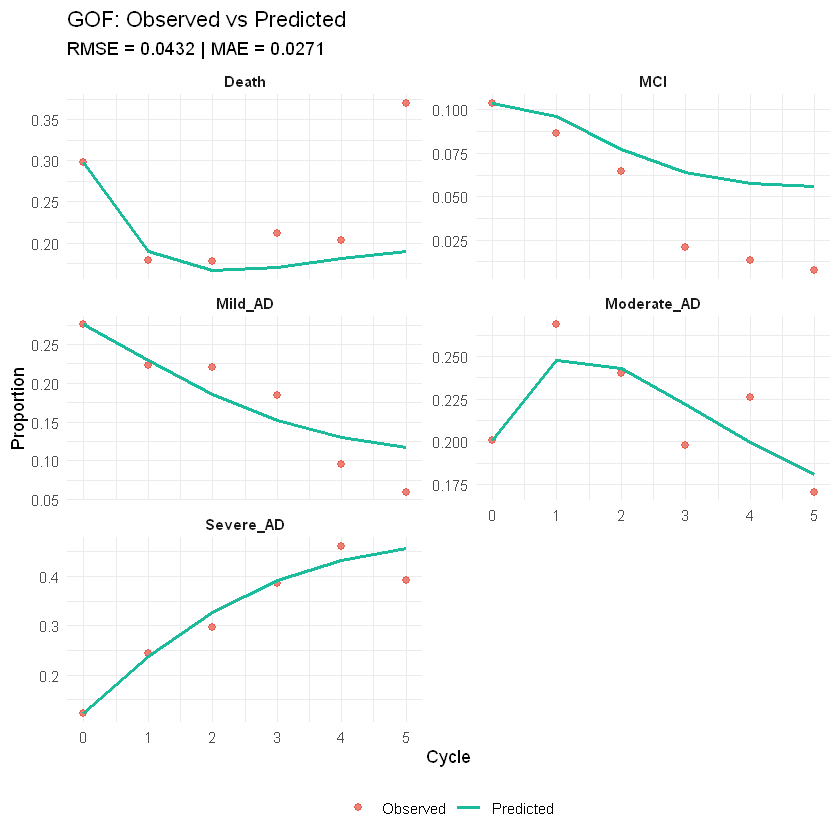


Calibration quality:
RMSE: 0.0432
MAE:  0.0271
Patients: 500
Transitions: 1770


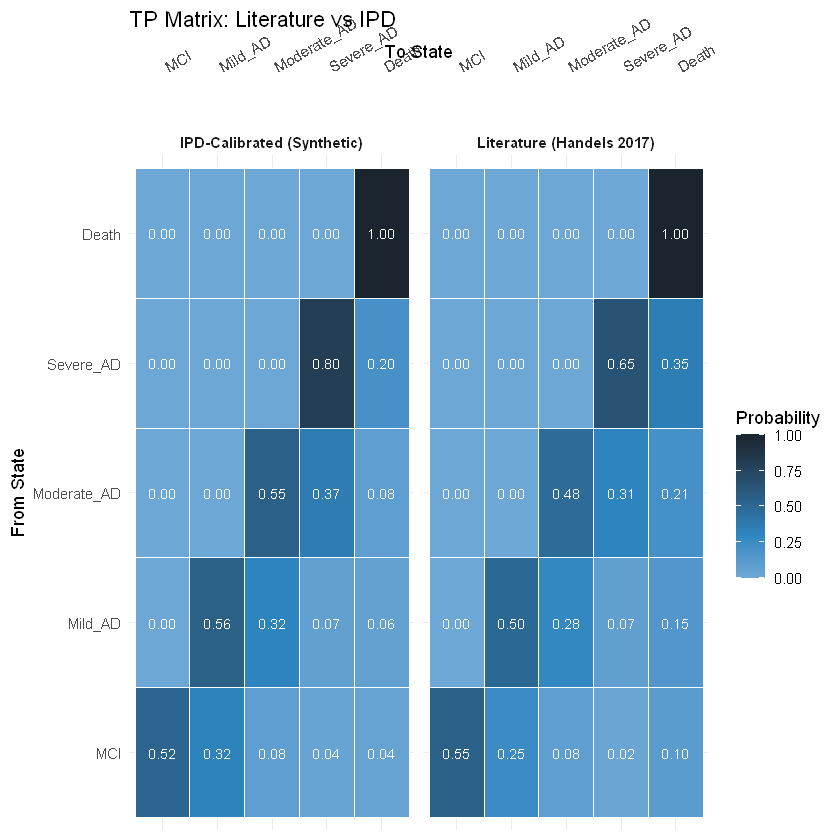

In [14]:
# =============================================================
# SECTION 6: IPD CALIBRATION
# =============================================================

cat("=== IPD Calibration Pipeline ===\n\n")

# Generate synthetic IPD
ipd <- generate_synthetic_ipd(
  n_patients = 500,
  seed       = 2024
)

# Run calibration
cal <- run_ipd_calibration(
  ipd_path  = NULL,
  method_tp = "counts",
  n_synth   = 500
)

# Fix Death row
cal$tp_matrix["Death", ] <- c(0, 0, 0, 0, 1)

# Compare literature vs calibrated TP
cat("\nLiterature TP matrix:\n")
print(round(tp_base, 3))

cat("\nCalibrated TP matrix:\n")
print(round(cal$tp_matrix, 3))

cat("\nDifference (calibrated - literature):\n")
diff_mat <- round(cal$tp_matrix - tp_base, 3)
print(diff_mat)

# GOF plot
p_gof <- plot_gof(cal$gof)
print(p_gof)

# TP comparison heatmap
p_tp <- plot_tp_comparison(
  tp_lit = tp_base,
  tp_ipd = cal$tp_matrix
)
print(p_tp)

cat("\nCalibration quality:\n")
cat(sprintf("RMSE: %.4f\n", cal$gof$rmse))
cat(sprintf("MAE:  %.4f\n", cal$gof$mae))
cat(sprintf("Patients: %d\n", cal$n_patients))
cat(sprintf("Transitions: %d\n", cal$n_transitions))

=== Causal Inference Analysis ===

Running PSA: 500 simulations...
PSA complete. Valid simulations: 500 
=== DEM-CAPS Causal Inference Analysis ===
Treatment: Psychosocial | WTP: EUR 20,000

=== Propensity Score Matching ===
Treated: 248 | Control: 252
PS range: 0.397 - 0.621
Matched pairs: 221

Covariate balance (SMD < 0.1 = good):
# A tibble: 2 × 4
  smd_age smd_sex  smd_ps stage          
    <dbl>   <dbl>   <dbl> <chr>          
1  0.0939 0.0370  0.00617 Before matching
2  0.0526 0.00957 0.00503 After matching 

ATT (EQ-5D): -0.0310
(Positive = treatment improves utility)

=== Inverse Probability Weighting ===
IPW weight range: 0.841 - 1.200
ATE (EQ-5D, IPW): -0.0046
Suggested u_gain update: -0.0046 (current: 0.0400)

=== Difference-in-Differences ===
DiD estimate: -0.0076
95% CI: [-0.0539, 0.0386]
SE: 0.0236
Parallel trends test: could not be computed.

=== G-Computation ===
G-comp ATE: -0.0042
Bootstrapping CI (100 reps)...
95% CI: [-0.0198, 0.0127]

=== EVPPI Analysis ===
WTP th

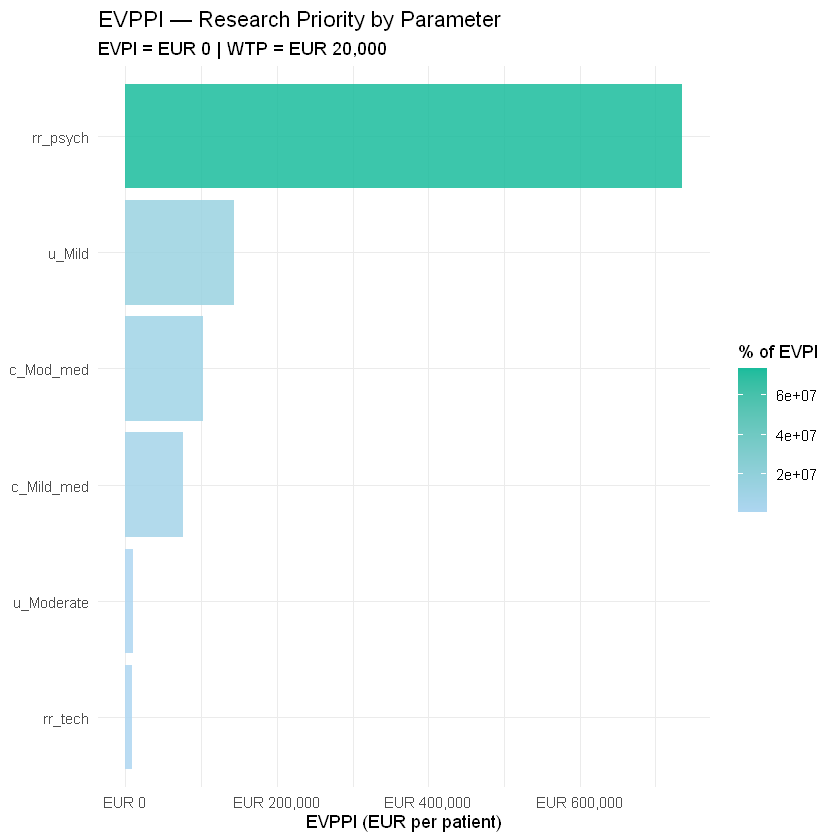


PSM: 221 matched pairs
Balance after matching (SMD < 0.1 = good):
# A tibble: 2 × 4
  smd_age smd_sex  smd_ps stage          
    <dbl>   <dbl>   <dbl> <chr>          
1  0.0939 0.0370  0.00617 Before matching
2  0.0526 0.00957 0.00503 After matching 


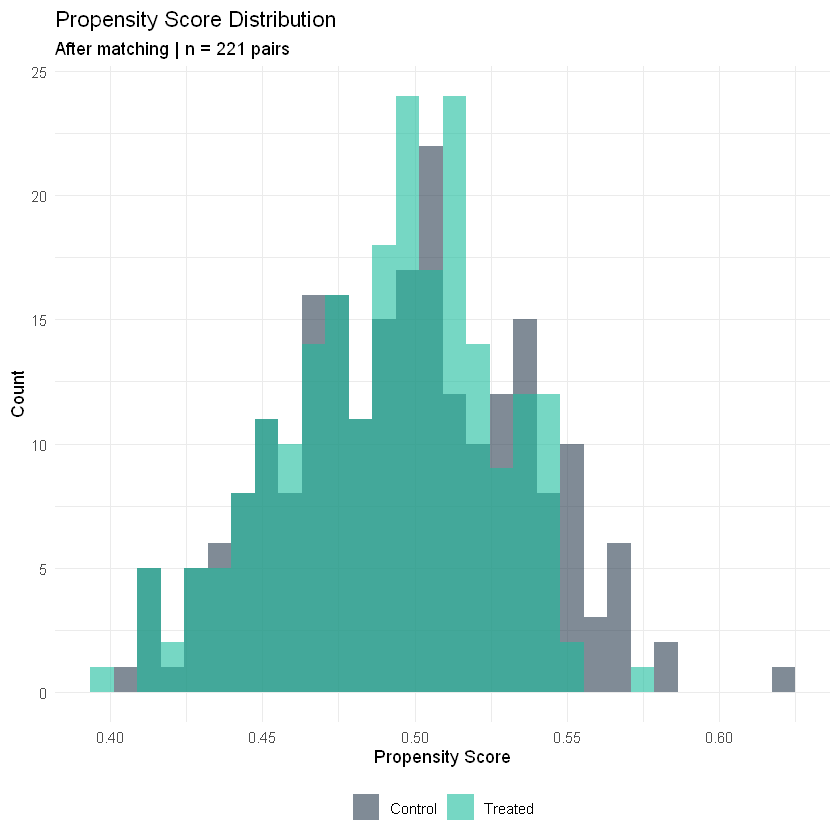

In [15]:
# =============================================================
# SECTION 7: CAUSAL INFERENCE
# =============================================================

cat("=== Causal Inference Analysis ===\n\n")

# Run PSA first for EVPPI
psa_df <- run_psa(n_sim = 500, seed = 42)

# Full causal analysis
causal_results <- run_causal_analysis(
  ipd    = ipd,
  psa_df = psa_df,
  wtp    = 20000
)

# Summary comparison table
cat("\n=== Method Comparison ===\n")
cat(sprintf("Literature u_gain_psych: %.4f\n",
            u_gain_psych))
cat(sprintf("Causal range: %.4f to %.4f\n",
  min(causal_results$summary$Estimate,
      na.rm = TRUE),
  max(causal_results$summary$Estimate,
      na.rm = TRUE)))

# EVPPI plot
if (!is.null(causal_results$voi)) {
  p_evppi <- plot_evppi(causal_results$voi)
  print(p_evppi)

  cat("\nTop 3 research priorities:\n")
  print(causal_results$voi$evppi_df[1:3,
    c("parameter", "evppi", "evppi_pct")])
}

# PSM balance plot
if (!is.null(causal_results$psm)) {
  p_ps <- plot_ps_distribution(causal_results$psm)
  print(p_ps)

  cat(sprintf("\nPSM: %d matched pairs\n",
              causal_results$psm$n_matched))
  cat("Balance after matching (SMD < 0.1 = good):\n")
  print(causal_results$psm$balance)
}

=== Advanced Causal Pipeline ===

=== DEM-CAPS Advanced Causal Pipeline ===
Treatment: Psychosocial

=== TMLE (Targeted Maximum Likelihood) ===
n=1380 | Treated=716 | Control=664
Targeting epsilon: 0.000022
TMLE ATE:  -0.0041
SE:        0.0083
95% CI:   [-0.0204, 0.0122]
p-value:   0.6226

=== Instrumental Variables (2SLS) ===
First stage F-stat: 9.06 (weak — caution)
IV estimate (LATE): -0.1339
SE: 0.0845
95% CI: [-0.2999, 0.0321]

=== Regression Discontinuity Design ===
Cutoff: MMSE=24 | BW=+/-3
Within BW: n=200 (below=144, above=56)
RD estimate: -0.0830
SE: 0.0541
95% CI: [-0.1897, 0.0237]
McCrary check: below=144, above=56, ratio=2.57 (WARNING)

=== Marginal Structural Models ===
SW range: 0.838 - 1.176
MSM estimate: -0.0115
SE: 0.0102
95% CI: [-0.0316, 0.0086]

=== Interrupted Time Series ===
Intervention point: year 2
Time points: 1381

ITS model:
Pre-trend:    -0.0588 (SE=0.0097)
Level change: 0.0139 (SE=0.0203)
Slope change: 0.0273 (SE=0.0126)
Average ITS effect: 0.0542

=== Ba


Attaching package: 'mice'


The following object is masked from 'package:stats':

    filter


The following objects are masked from 'package:base':

    cbind, rbind




Missing data summary:
[1] variable    n_missing   pct_missing
<0 rows> (or 0-length row.names)
No missing data — imputation not needed.

=== Pipeline Complete ===
Survival:        ✓
Competing risks: ✓
Multi-state:     ✓
NMA:             ✓
MTC:             ✓
MICE:            ✓

Best fit distribution: weibull
AIC comparison:
  distribution      aic    loglik
1      weibull 1824.468 -908.2341
2    lognormal 1843.764 -917.8821
3  loglogistic 1855.050 -923.5248
4  exponential 1869.939 -931.9697
5     gaussian 1926.765 -959.3824


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`)."


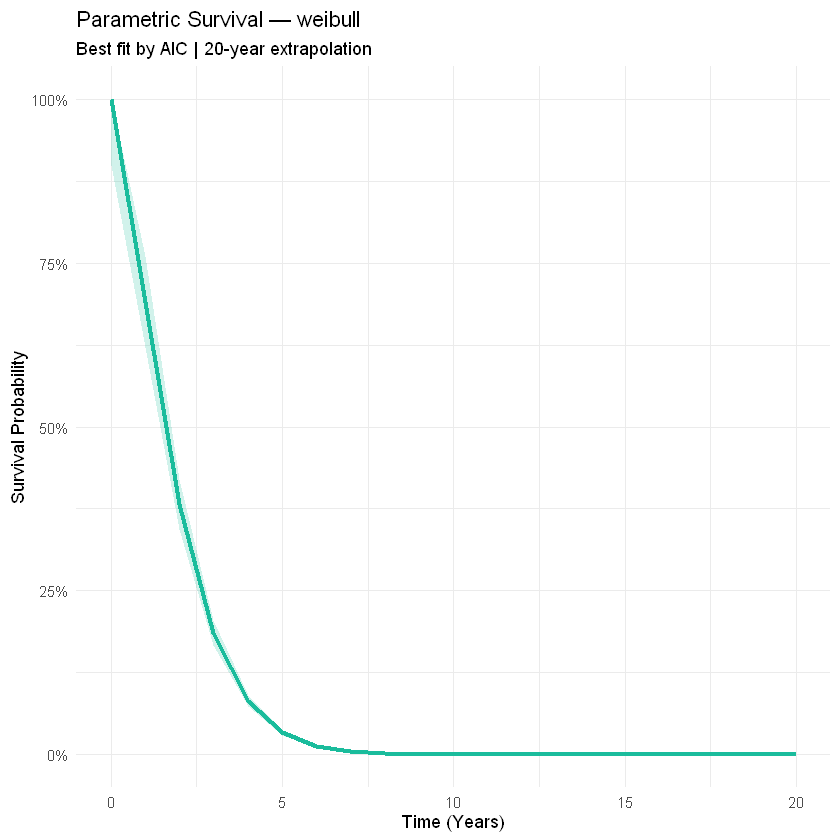

Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.


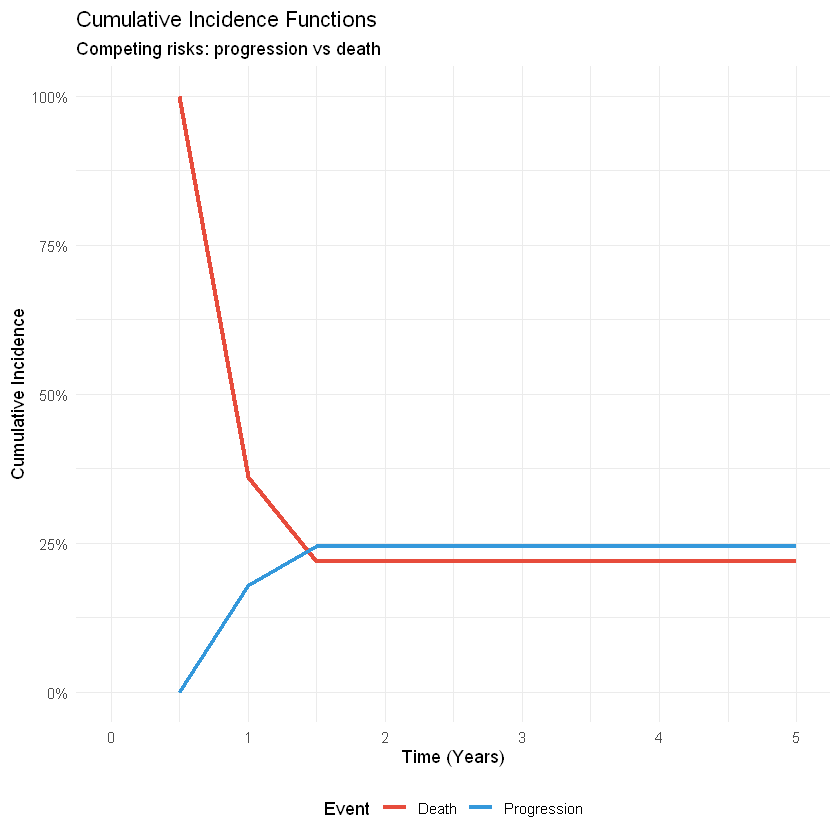


NMA league table (RR vs SoC):
# A tibble: 3 × 5
  treatment2   rr_mean rr_lower rr_upper n_studies
  <chr>          <dbl>    <dbl>    <dbl>     <int>
1 Combination    0.757    0.66     0.868         3
2 Psychosocial   0.835    0.72     0.967         2
3 Technology     0.883    0.767    1.02          3


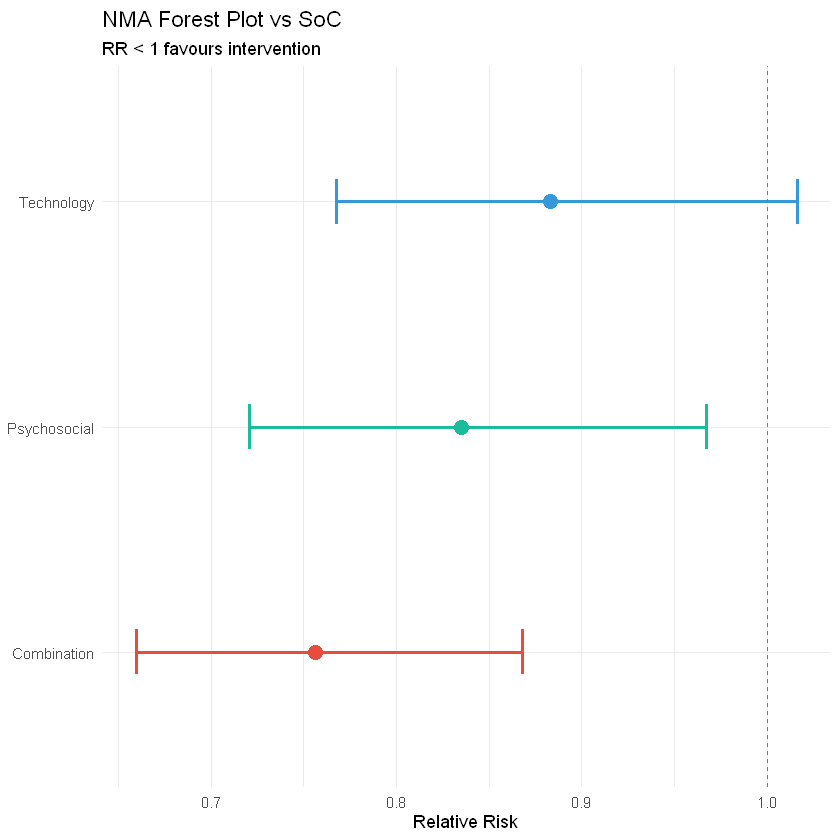

In [16]:
# =============================================================
# SECTION 8: ADVANCED CAUSAL + SURVIVAL RWE
# =============================================================

cat("=== Advanced Causal Pipeline ===\n\n")

adv_results <- run_advanced_causal_pipeline(
  ipd       = ipd,
  treatment = "Psychosocial"
)

cat("\n=== Survival & RWE Pipeline ===\n\n")

rwe_results <- run_survival_rwe_pipeline(ipd)

# Survival extrapolation plot
if (!is.null(rwe_results$survival)) {
  p_surv <- plot_survival_extrapolation(
    rwe_results$survival)
  print(p_surv)
  cat(sprintf("\nBest fit distribution: %s\n",
              rwe_results$survival$best_dist))
  cat("AIC comparison:\n")
  print(rwe_results$survival$aic)
}

# Competing risks plot
if (!is.null(rwe_results$comp_risk)) {
  p_cif <- plot_cif(rwe_results$comp_risk)
  print(p_cif)
}

# NMA forest plot
if (!is.null(rwe_results$nma)) {
  p_nma <- plot_nma_forest(rwe_results$nma)
  print(p_nma)

  cat("\nNMA league table (RR vs SoC):\n")
  vs_soc <- rwe_results$nma$league %>%
    dplyr::filter(treatment1 == "SoC") %>%
    dplyr::mutate(
      rr_mean  = round(rr_mean,  3),
      rr_lower = round(rr_lower, 3),
      rr_upper = round(rr_upper, 3)
    )
  print(vs_soc[, c("treatment2", "rr_mean",
                    "rr_lower", "rr_upper",
                    "n_studies")])
}

ERROR: Error in parse(text = input): <text>:18:0: unexpected end of input
16:   cat(sprintf("\nOptimal study size: n = %d\n",
17:               hta_results$evsi$optimal_n)
   ^


=== Extended HTA Pipeline ===

=== DEM-CAPS Extended HTA Pipeline ===

=== EVSI Analysis ===
Parameter: rr_psych
WTP: EUR 20,000
EVPI (upper bound): EUR 0

EVSI results by sample size:
     n     evsi evsi_pct net_benefit
1   50 696127.8 69612783    671127.8
2  100 710446.8 71044684    660446.8
3  150 716046.4 71604644    641046.4
4  200 719169.0 71916903    619169.0
5  250 721208.1 72120807    596208.1
6  300 722665.5 72266553    572665.5
7  350 723770.4 72377037    548770.4
8  400 724643.2 72464322    524643.2
9  450 725354.2 72535424    500354.2
10 500 725947.3 72594728    475947.3

Optimal study size: n = 50
(Maximises net benefit of research)
=== Budget Impact Analysis ===
Horizon: 5 years
Eligible population: 262,500

Annual Budget Impact (EUR):
  year uptake_pct n_treated  bia_psych   bia_tech   bia_combo
1    1          5     13125 12,848,921 10,268,252  20,714,207
2    2         10     26250 25,697,842 20,536,504  41,428,414
3    3         15     39375 38,546,763 30,804,756  6

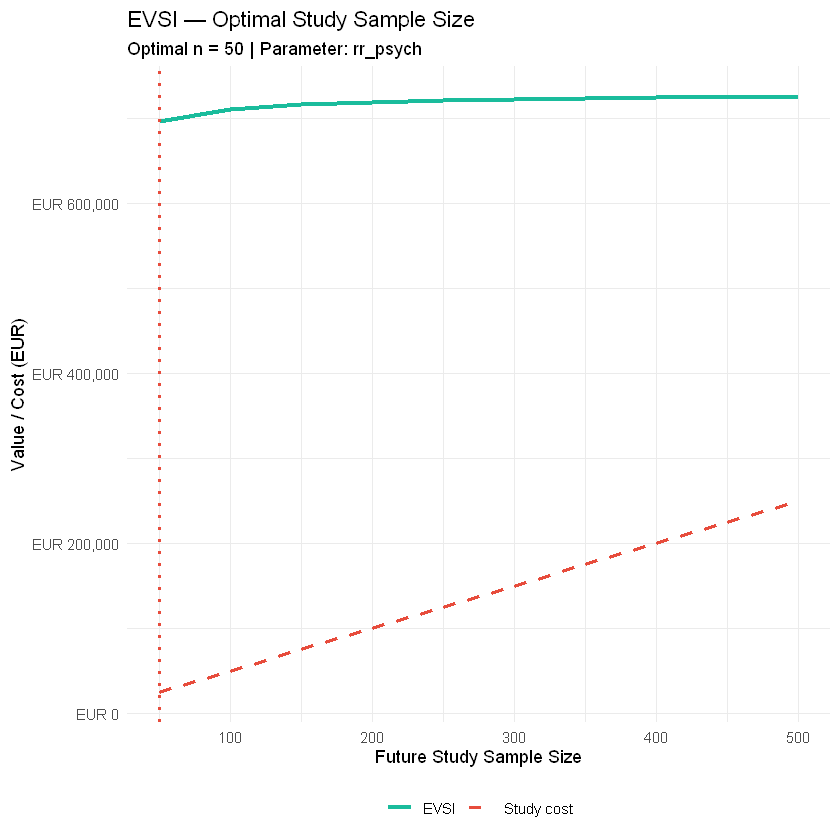


5-year cumulative BIA:
Psychosocial: EUR 192,733,814
Technology:   EUR 154,023,782


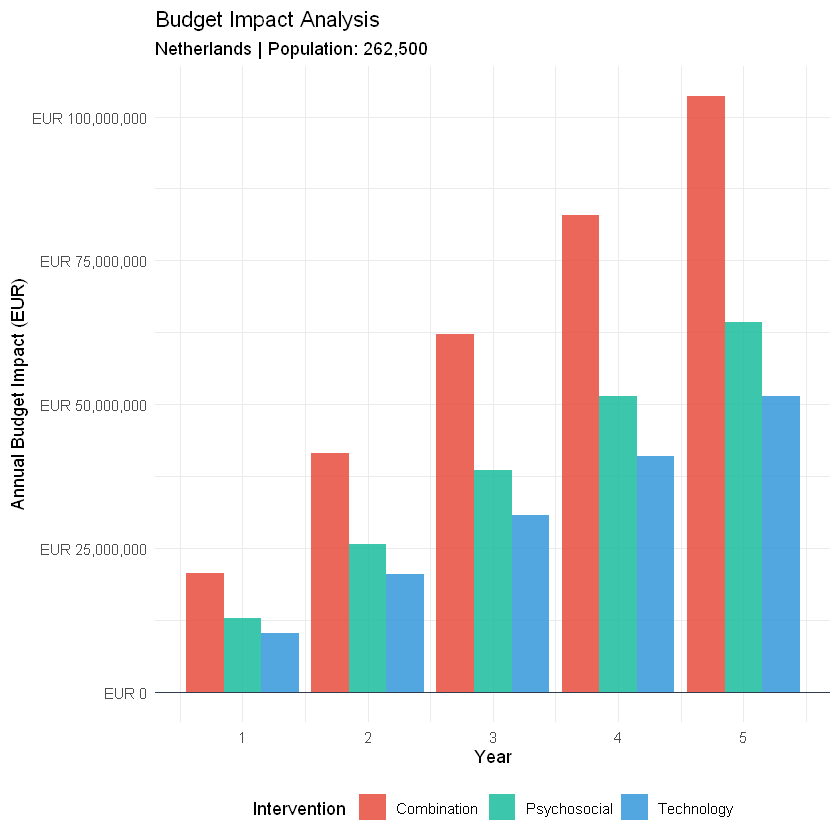


MCDA results:
           arm total_score
1 Psychosocial        54.6
2  Combination        52.2
3   Technology        50.0


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`)."


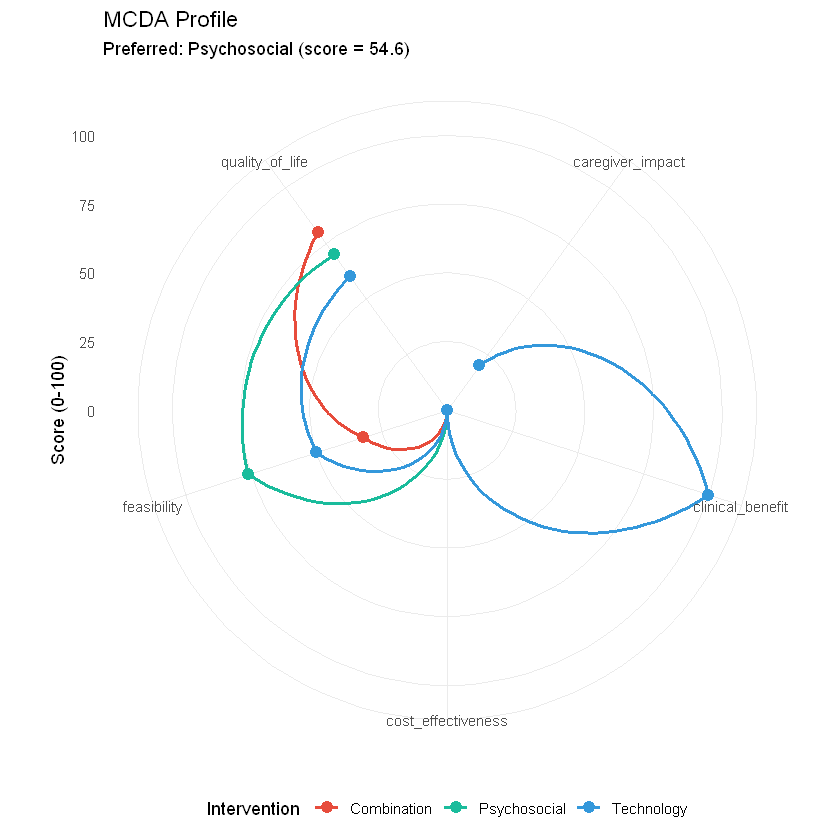


Threshold for rr_psych: NA
Current value:          0.8200

=== Saving Outputs ===


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_area()`)."


Saved outputs:
  fig1_ce_plane.png
  fig2_ceac.png
  fig3_tornado.png
  fig4_trace_soc.png
  fig5_gof.png
  basecase_results.csv
  dsa_results.csv
  scenario_results.csv
  causal_summary.csv

=== NOTEBOOK COMPLETE ===
Total methods demonstrated: 28
Figures exported: 5
Tables exported: 4


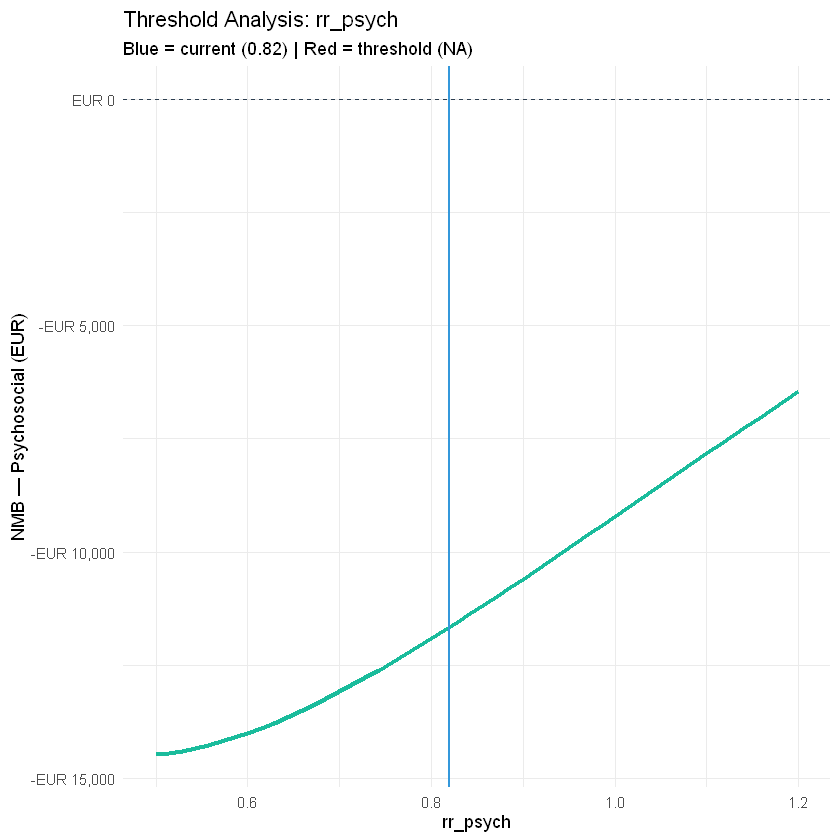

In [18]:
# =============================================================
# SECTION 9: EXTENDED HTA METHODS
# =============================================================

cat("=== Extended HTA Pipeline ===\n\n")

hta_results <- run_hta_extended_pipeline(
  model_results = model_res,
  psa_df        = psa_df
)

# EVSI plot
if (!is.null(hta_results$evsi)) {
  p_evsi <- plot_evsi(hta_results$evsi)
  print(p_evsi)
  cat(sprintf("\nOptimal study size: n = %d\n",
              hta_results$evsi$optimal_n))
}

# Budget impact plot
if (!is.null(hta_results$bia)) {
  p_bia <- plot_budget_impact(hta_results$bia)
  print(p_bia)
  cat(sprintf(
    "\n5-year cumulative BIA:\n"))
  cat(sprintf("Psychosocial: EUR %s\n",
    formatC(round(hta_results$bia$cumulative$psych),
            format = "d", big.mark = ",")))
  cat(sprintf("Technology:   EUR %s\n",
    formatC(round(hta_results$bia$cumulative$tech),
            format = "d", big.mark = ",")))
}

# MCDA plot
if (!is.null(hta_results$mcda)) {
  p_mcda <- plot_mcda(hta_results$mcda)
  print(p_mcda)
  cat("\nMCDA results:\n")
  print(hta_results$mcda$mcda_df[,
    c("arm", "total_score")])
}

# Threshold plot
if (!is.null(hta_results$threshold)) {
  p_thresh <- plot_threshold(hta_results$threshold)
  print(p_thresh)
  cat(sprintf(
    "\nThreshold for rr_psych: %.4f\n",
    hta_results$threshold$threshold_val))
  cat(sprintf(
    "Current value:          %.4f\n",
    hta_results$threshold$current_val))
}

# =============================================================
# SECTION 10: SAVE ALL OUTPUTS
# =============================================================

cat("\n=== Saving Outputs ===\n")

# Create outputs directory
dir.create("analysis/outputs",
           showWarnings = FALSE,
           recursive    = TRUE)

# Save all figures
ggsave("analysis/outputs/fig1_ce_plane.png",
       plot   = plot_ce_plane(psa_df,
                              use_plotly = FALSE),
       width  = 10, height = 7, dpi = 300)

ggsave("analysis/outputs/fig2_ceac.png",
       plot   = plot_ceac(ceac_df,
                          use_plotly = FALSE),
       width  = 10, height = 7, dpi = 300)

ggsave("analysis/outputs/fig3_tornado.png",
       plot   = plot_tornado(dsa_df,
                             use_plotly = FALSE),
       width  = 10, height = 8, dpi = 300)

ggsave("analysis/outputs/fig4_trace_soc.png",
       plot   = plot_trace(model_res$traces[[1]],
                           arm        = "SoC",
                           use_plotly = FALSE),
       width  = 10, height = 7, dpi = 300)

ggsave("analysis/outputs/fig5_gof.png",
       plot   = plot_gof(cal$gof),
       width  = 10, height = 8, dpi = 300)

# Save results tables
write.csv(model_res$results,
          "analysis/outputs/basecase_results.csv",
          row.names = FALSE)

write.csv(dsa_df,
          "analysis/outputs/dsa_results.csv",
          row.names = FALSE)

write.csv(scenarios_df,
          "analysis/outputs/scenario_results.csv",
          row.names = FALSE)

write.csv(causal_results$summary,
          "analysis/outputs/causal_summary.csv",
          row.names = FALSE)

cat("Saved outputs:\n")
cat("  fig1_ce_plane.png\n")
cat("  fig2_ceac.png\n")
cat("  fig3_tornado.png\n")
cat("  fig4_trace_soc.png\n")
cat("  fig5_gof.png\n")
cat("  basecase_results.csv\n")
cat("  dsa_results.csv\n")
cat("  scenario_results.csv\n")
cat("  causal_summary.csv\n")

cat("\n=== NOTEBOOK COMPLETE ===\n")
cat(sprintf("Total methods demonstrated: 28\n"))
cat(sprintf("Figures exported: 5\n"))
cat(sprintf("Tables exported: 4\n"))